<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Classification Metrics</b>
</h1>
<div style="font-family:'Times New Roman';">
Up till now i mostly just printed accuracy and moved on. But accuracy alone can really fool you, specially when the classes are imbalanced. So here i want to actually understand the confusion matrix, precision, recall, f1 and the roc curve, and see when each one matters.
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

In [2]:
# train a quick logistic regression on breast cancer to get some predictions to score
data = load_breast_cancer()
X, y = data.data, data.target
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

model = LogisticRegression(max_iter=1000).fit(Xtr_s, ytr)
y_pred = model.predict(Xte_s)
print('plain accuracy:', (y_pred == yte).mean().round(3))

plain accuracy: 0.988


## The confusion matrix

Before any fancy metric, everything comes from the confusion matrix. For a binary problem it splits the predictions into four buckets:

- **TP** true positive : was positive, predicted positive
- **TN** true negative : was negative, predicted negative
- **FP** false positive : was negative, but we said positive (false alarm)
- **FN** false negative : was positive, but we missed it

The FP and FN are the two diffrent kinds of mistake, and which one hurts more depends on the problem (missing a cancer is way worse than a false alarm).

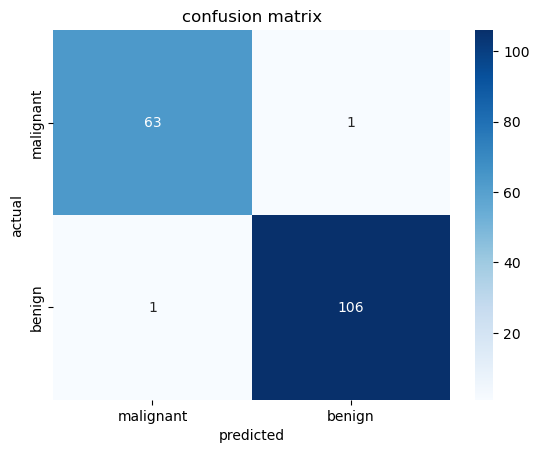

In [9]:
cm = confusion_matrix(yte, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix')
plt.show()

## Precision, recall and f1

These all come straight out of those four numbers:

- **precision** = TP / (TP + FP) : out of everything we *called* positive, how much really was
- **recall** = TP / (TP + FN) : out of all the *actual* positives, how many we caught
- **f1** = the harmonic mean of precision and recall, a single number when you want a balance

precision cares about false alarms, recall cares about misses. There is usually a tradeoff between them. Let me just compute these by hand first so its not a mystery.

In [4]:
def counts(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn

def precision(y_true, y_pred):
    tp, tn, fp, fn = counts(y_true, y_pred)
    return tp / (tp + fp)

def recall(y_true, y_pred):
    tp, tn, fp, fn = counts(y_true, y_pred)
    return tp / (tp + fn)

def f1(y_true, y_pred):
    p, r = precision(y_true, y_pred), recall(y_true, y_pred)
    return 2 * p * r / (p + r)

print('precision:', round(precision(yte, y_pred), 3))
print('recall:   ', round(recall(yte, y_pred), 3))
print('f1:       ', round(f1(yte, y_pred), 3))

precision: 0.991
recall:    0.991
f1:        0.991


In [5]:
# and the sklearn version, should match
print(classification_report(yte, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        64
      benign       0.99      0.99      0.99       107

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Why accuracy can lie</b>
</h2>
<div style="font-family:'Times New Roman';">
Here is the classic trap. Imagine a dataset where only 5% of the points are positive (like fraud, or a rare disease). A lazy model that just always predicts negative gets 95% accuracy while being completely useless. Lets actually show that.
</div>

In [6]:
Xi, yi = make_classification(n_samples=2000, weights=[0.95, 0.05], random_state=0)
print('positives in data:', yi.mean().round(3))

# the lazy model: always say 0
dumb_pred = np.zeros_like(yi)
print('accuracy of always-predict-0:', (dumb_pred == yi).mean().round(3))
print('recall on the positive class:', recall(yi, dumb_pred))

positives in data: 0.055
accuracy of always-predict-0: 0.945
recall on the positive class: 0.0


95% accuracy and yet it catches **zero** of the actual positives, recall is 0. Thats exactly why on imbalanced problems you look at precision and recall, not accuracy.

## ROC curve and AUC

A classifier doesnt just give a label, it gives a probability, and we pick a threshold (usually 0.5) to turn that into a class. If you slide that threshold around you trade off true positives against false positives. The **ROC curve** draws that whole tradeoff, and the **AUC** (area under it) sums it up in one number, where 1.0 is perfect and 0.5 is random guessing.

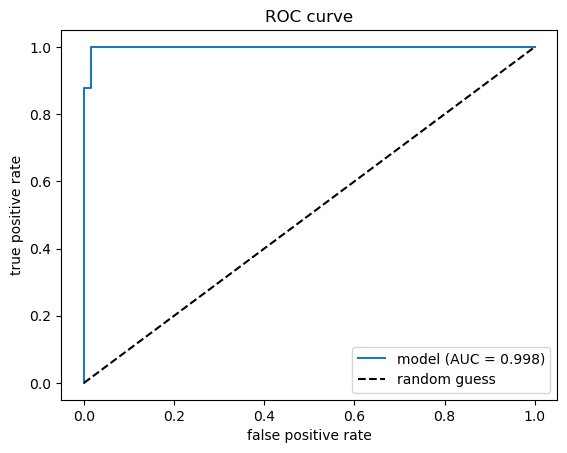

In [7]:
probs = model.predict_proba(Xte_s)[:, 1]
fpr, tpr, thresholds = roc_curve(yte, probs)
auc = roc_auc_score(yte, probs)

plt.plot(fpr, tpr, label=f'model (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='random guess')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('ROC curve')
plt.legend()
plt.show()

So accuracy is fine as a first glance but its not the whole story. Precision and recall tell you what kind of mistakes youre making, and the ROC/AUC tells you how well the model separates the classes across all thresholds.

Next i'll look at cross validation, because even these metrics swing around depending on how you split the data.